# Figure2 (Error Evaluation)

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

**Data for Figure2**  
Code for the data: `fig2_resampling_error.py`

In [2]:
# Data Load
plotdata = pickle.load(open('./data/fig2_resampling_error.pkl', 'rb'))

d_unique = {
    'uni': [np.mean(plotdata['d']['uni'][f"{n}"]) for n in plotdata['n']],
    'lss': [np.mean(plotdata['d']['lss'][f"{n}"]) for n in plotdata['n']],
    'kls': [np.mean(plotdata['d']['kls'][f"{n}"]) for n in plotdata['n']],
}

e_absolute = {
    'uni': list(plotdata['eps1']['uni'].values()),
    'lss': list(plotdata['eps1']['lss'].values()),
    'kls': list(plotdata['eps1']['kls'].values()),
}

e_relative = {
    'uni': list(plotdata['eps2']['uni'].values()),
    'lss': list(plotdata['eps2']['lss'].values()),
    'kls': list(plotdata['eps2']['kls'].values()),
}

smp_unif = {
    'absolute': list(plotdata['tau1']['uni'].values()),
    'relative': list(plotdata['tau2']['uni'].values()),
}

**Figure2 (a)**

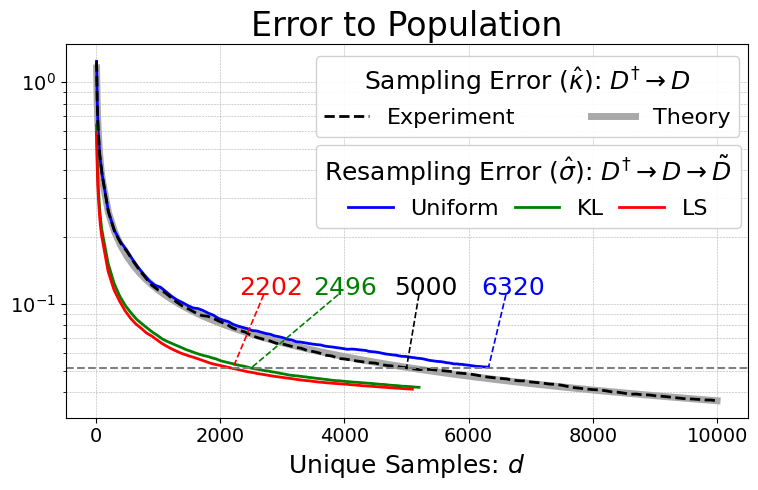

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

# Resampling Error
(line_uni,) = ax.plot(d_unique['uni'], e_relative['uni'], '-', linewidth=2, label='Uniform', color='blue')
(line_kls,) = ax.plot(d_unique['kls'], e_relative['kls'], '-', linewidth=2, label='KL', color='green')
(line_lss,) = ax.plot(d_unique['lss'], e_relative['lss'], '-', linewidth=2, label='LS', color='red')

# Sampling Error
n = np.asarray(plotdata['n'], dtype=float)
(line_exp, ) = ax.plot(n, smp_unif['relative'], '--', color='black', linewidth=2, label='Experiment', zorder=2)
sigma_N = smp_unif['relative'][-1]
e_theory = sigma_N * np.sqrt(10000.0 / n)
(line_the, ) = ax.plot(n, e_theory, '-', color='darkgray', linewidth=5, label='Theory', zorder=1)

# Baseline
pos_n_5k = plotdata['n'].index(5000)
baseline = smp_unif['relative'][pos_n_5k]
ax.axhline(y=baseline, color='gray', linestyle='--')

ax.set_yscale('log')
ax.grid(True, which='both', linestyle='--', linewidth=0.4)
ax.set_xlabel(r'Unique Samples: $d$', fontsize=18)
ax.set_title(r'Error to Population', fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=14)

# Annotate Unique Samples
text_y = 0.11
pos_n_lss = plotdata['n'].index(2900)
ax.text(2300, text_y, f"{round(d_unique['lss'][pos_n_lss])}", fontsize=18, color='red')
ax.plot([2700, d_unique['lss'][pos_n_lss]], [text_y, e_relative['lss'][pos_n_lss]], 'r--', linewidth=1.2)

pos_n_kls = plotdata['n'].index(3300)
ax.text(3500, text_y, f"{round(d_unique['kls'][pos_n_kls])}", fontsize=18, color='green')
ax.plot([3900, d_unique['kls'][pos_n_kls]], [text_y, e_relative['kls'][pos_n_kls]], 'g--', linewidth=1.2)

ax.text(4800, text_y, f"5000", fontsize=18, color='black')
ax.plot([5200, 5000], [text_y, baseline], 'k--', linewidth=1.2)

ax.text(6200, text_y, f"{round(d_unique['uni'][-1])}", fontsize=18, color='blue')
ax.plot([6600, d_unique['uni'][-1]], [text_y, e_relative['uni'][-1]], 'b--', linewidth=1.2)

legend1 = ax.legend(
    handles=[line_uni, line_kls, line_lss],
    title=r'Resampling Error ($\hat \sigma$): $D^{\dagger} \rightarrow D \rightarrow \tilde{D}$',
    bbox_to_anchor=(0.35, 0.62),
    loc='center left',
    fontsize=16, 
    framealpha=0.9, 
    ncol=3,
    columnspacing=0.7,
)
ax.add_artist(legend1)
legend1.get_title().set_fontsize(18)

legend2 = ax.legend(
    handles=[line_exp, line_the],
    bbox_to_anchor=(0.35, 0.86),
    title=r'Sampling Error ($\hat \kappa$): $D^{\dagger} \rightarrow D$',
    loc='center left',
    fontsize=16,
    framealpha=0.9,
    ncol=2,
    columnspacing=3.4,
)
legend2.get_title().set_fontsize(18)

plt.tight_layout()
plt.savefig('./figures/fig2a_relative.pdf', format='pdf', bbox_inches='tight')
plt.savefig('./figures/fig2a_relative.png', format='png', bbox_inches='tight', dpi=500)
plt.show()

**Figure2 (b)**

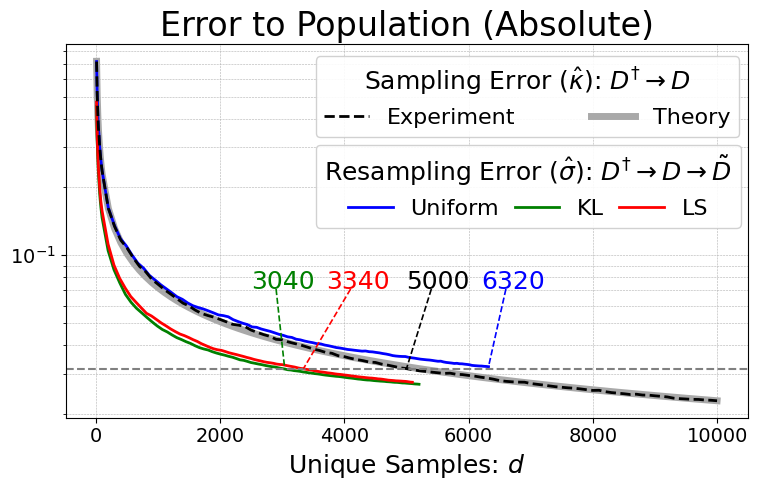

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

# Resampling Error
(line_uni,) = ax.plot(d_unique['uni'], e_absolute['uni'], '-', linewidth=2, label='Uniform', color='blue')
(line_kls,) = ax.plot(d_unique['kls'], e_absolute['kls'], '-', linewidth=2, label='KL', color='green')
(line_lss,) = ax.plot(d_unique['lss'], e_absolute['lss'], '-', linewidth=2, label='LS', color='red')

# Sampling Error
n = np.asarray(plotdata['n'], dtype=float)
(line_exp, ) = ax.plot(n, smp_unif['absolute'], '--', color='black', linewidth=2, label='Experiment', zorder=2)
sigma_N = smp_unif['absolute'][-1]
e_theory = sigma_N * np.sqrt(10000.0 / n)
(line_the, ) = ax.plot(n, e_theory, '-', color='darkgray', linewidth=5, label='Theory', zorder=1)

# Baseline
pos_n_5k = plotdata['n'].index(5000)
baseline = smp_unif['absolute'][pos_n_5k]
ax.axhline(y=baseline, color='gray', linestyle='--')

ax.set_yscale('log')
ax.grid(True, which='both', linestyle='--', linewidth=0.4)
ax.set_xlabel(r'Unique Samples: $d$', fontsize=18)
ax.set_title(r'Error to Population (Absolute)', fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=14)

# Annotate Unique Samples
text_y = 0.071
pos_n_kls = plotdata['n'].index(4300)
plt.text(2500, text_y, f"{round(d_unique['kls'][pos_n_kls])}", fontsize=18, color='green')
plt.plot([2900, d_unique['kls'][pos_n_kls]], [text_y, e_absolute['kls'][pos_n_kls]], 'g--', linewidth=1.2)

pos_n_lss = plotdata['n'].index(5100)
plt.text(3700, text_y, f"{round(d_unique['lss'][pos_n_lss])}", fontsize=18, color='red')
plt.plot([4100, d_unique['lss'][pos_n_lss]], [text_y, e_absolute['lss'][pos_n_lss]], 'r--', linewidth=1.2)

plt.text(5000, text_y, f"5000", fontsize=18, color='black')
plt.plot([5400, 5000], [text_y, baseline], 'k--', linewidth=1.2)

plt.text(6200, text_y, f"{round(d_unique['uni'][-1])}", fontsize=18, color='blue')
plt.plot([6600, d_unique['uni'][-1]], [text_y, e_absolute['uni'][-1]], 'b--', linewidth=1.2)

legend1 = ax.legend(
    handles=[line_uni, line_kls, line_lss],
    title=r'Resampling Error ($\hat \sigma$): $D^{\dagger} \rightarrow D \rightarrow \tilde{D}$',
    bbox_to_anchor=(0.35, 0.62),
    loc='center left',
    fontsize=16, 
    framealpha=0.9, 
    ncol=3,
    columnspacing=0.7,
)
ax.add_artist(legend1)
legend1.get_title().set_fontsize(18)

legend2 = ax.legend(
    handles=[line_exp, line_the],
    bbox_to_anchor=(0.35, 0.86),
    title=r'Sampling Error ($\hat \kappa$): $D^{\dagger} \rightarrow D$',
    loc='center left',
    fontsize=16,
    framealpha=0.9,
    ncol=2,
    columnspacing=3.4,
)
legend2.get_title().set_fontsize(18)

plt.tight_layout()
plt.savefig('./figures/fig2b_absolute.pdf', format='pdf', bbox_inches='tight')
plt.savefig('./figures/fig2b_absolute.png', format='png', bbox_inches='tight', dpi=500)
plt.show()